#  Priorizar Hipotesis

In [1]:
#Importamos las librerias correspondientes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
#importamos los datos
hipotesis_df = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')
orders_df = pd.read_csv('/datasets/orders_us.csv')
visits_df = pd.read_csv('/datasets/visits_us.csv')

In [3]:
#Trabajaremos con hipotesis_df para la primera parte del analisis

In [4]:
#Primer vistazo a los datos
print(hipotesis_df.head(), '\n')
print(hipotesis_df.info())

                                          Hypothesis  Reach  Impact  \
0  Add two new channels for attracting traffic. T...      3      10   
1  Launch your own delivery service. This will sh...      2       5   
2  Add product recommendation blocks to the store...      8       3   
3  Change the category structure. This will incre...      8       3   
4  Change the background color on the main page. ...      3       1   

   Confidence  Effort  
0           8       6  
1           4      10  
2           7       3  
3           3       8  
4           1       1   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0

# Procedemos a calcular los Frameworks ICE y RICE para cada una de las hipotesis

## Framework ICE

In [5]:
#Obtenemos el Framework ICE
hipotesis_df['ICE'] = (hipotesis_df['Impact'] * hipotesis_df['Confidence']) / hipotesis_df['Effort']

In [6]:
#Ordenamos de manera descendente
hipotesis_df[['Hypothesis', 'ICE']].sort_values(by='ICE', ascending=False)

,Hypothesis,ICE
8,Launch a promotion that gives users discounts ...,16.200000
0,Add two new channels for attracting traffic. T...,13.333333
7,Add a subscription form to all the main pages....,11.200000
6,Show banners with current offers and sales on ...,8.000000
2,Add product recommendation blocks to the store...,7.000000
1,Launch your own delivery service. This will sh...,2.000000
5,Add a customer review page. This will increase...,1.333333
3,Change the category structure. This will incre...,1.125000
4,Change the background color on the main page. ...,1.000000


## Obtenemos el Framework RICE

In [7]:
#Obtenemos el Framework RICE
hipotesis_df['RICE'] = (hipotesis_df['Reach'] * hipotesis_df['Impact'] * hipotesis_df['Confidence']) / hipotesis_df['Effort']

In [8]:
#Ordenamos de Manera descendente
hipotesis_df[['Hypothesis', 'RICE']].sort_values(by='RICE', ascending=False)

,Hypothesis,RICE
7,Add a subscription form to all the main pages....,112.0
2,Add product recommendation blocks to the store...,56.0
0,Add two new channels for attracting traffic. T...,40.0
6,Show banners with current offers and sales on ...,40.0
8,Launch a promotion that gives users discounts ...,16.2
3,Change the category structure. This will incre...,9.0
1,Launch your own delivery service. This will sh...,4.0
5,Add a customer review page. This will increase...,4.0
4,Change the background color on the main page. ...,3.0


## Cambios en la priorizacion de hipotesis entre ICE y RICE

Se observan cambios en el orden de priorizacion entre el ICE y RICE, sin embargo, en ambos casos podemos descartar las hipotesis 1, 3, 4 y 5, ya que en ambos casos aparecen de ultimas en el orden de prioridad, pero con distinto orden, asi que directamente se podria sugerir enfocarse en las hipotesis 0, 2, 6, 7 y 8 ya que en ambos casos son las que lideran el orden de prioridad. Sin embargo, dado que tenemos los 4 parametros necesarios para obtener RICE (Reach, Impact, Confidence y Effort) optaria por sugerir inclinarnos mas hacia este listado, pues al incluir el parametro Reach, podemos aprovechar que tenemos los datos cuantitavos disponibles para una evaluacion mas precisa.

#  Análsis del test A/B

### Comenzamos a analizar el dataframe orders_df

In [9]:
#Primer vistazo a los datos
print(orders_df.head(), '\n')
print(orders_df.info())

   transactionId   visitorId        date  revenue group
0     3667963787  3312258926  2019-08-15     30.4     B
1     2804400009  3642806036  2019-08-15     15.2     B
2     2961555356  4069496402  2019-08-15     10.2     A
3     3797467345  1196621759  2019-08-15    155.1     B
4     2282983706  2322279887  2019-08-15     40.5     B 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB
None


In [10]:
#Buscamos valores duplicados en orders_df
orders_df.duplicated().sum()

0

In [11]:
#Buscamos valores duplicados en orders_df['transactionId']
orders_df['transactionId'].duplicated().sum()

0

In [12]:
#Buscamos valores duplicados en orders_df['visitorId']
orders_df['visitorId'].duplicated().sum()

166

In [13]:
#Cantidad unica de ID de los visitantes
orders_df['visitorId'].nunique()

1031

In [14]:
duplciated_users = orders_df[orders_df['visitorId'].duplicated()].sort_values(by='visitorId')
duplciated_users.head(20)

,transactionId,visitorId,date,revenue,group
703,4293855558,8300375,2019-08-07,30.5,A
823,2971973105,199603092,2019-08-27,45.9,A
246,437656952,199603092,2019-08-02,55.7,B
1102,1941707234,199603092,2019-08-12,100.0,A
134,62794304,199603092,2019-08-22,110.3,A
1013,83566152,232979603,2019-08-31,5.9,A
590,3702128013,237748145,2019-08-20,20.8,A
716,972407388,237748145,2019-08-27,10.2,A
41,2594268419,237748145,2019-08-15,20.8,A
1097,3357467820,237748145,2019-08-12,10.2,A


In [15]:
#Se observa que existen visitantes que caen en ambos grupos, A y B
#Procederemos revisar cuantos visitantes tenemos para cada uno de los grupos
visitors_per_group = orders_df.groupby('group', as_index=False).agg({'visitorId':'count'})
visitors_per_group

,group,visitorId
0,A,557
1,B,640


In [16]:
#El objetivo es encontrar a los usurios que estan aprticipando en ambos grupos para eliminarlos y no alterar los resultados
visitors_with_two_groups = orders_df.groupby('visitorId')['group'].nunique().reset_index()
visitors_with_two_groups = visitors_with_two_groups[visitors_with_two_groups['group']>1] 
visitors_with_two_groups.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 58 entries, 2 to 1026
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   visitorId  58 non-null     int64
 1   group      58 non-null     int64
dtypes: int64(2)
memory usage: 1.4 KB


In [17]:
#Se detectan 58 usurios con participacion en ambos grupos, los cuales seran removidos
filtered_orders = orders_df[~orders_df['visitorId'].isin(visitors_with_two_groups['visitorId'])].reset_index()
filtered_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1016 entries, 0 to 1015
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          1016 non-null   int64  
 1   transactionId  1016 non-null   int64  
 2   visitorId      1016 non-null   int64  
 3   date           1016 non-null   object 
 4   revenue        1016 non-null   float64
 5   group          1016 non-null   object 
dtypes: float64(1), int64(3), object(2)
memory usage: 47.8+ KB


In [18]:
filtered_orders['visitorId'].duplicated().sum()

43

In [19]:
#Hemos eliminado a los visitantes con participacion en ambos grupos, es normal tener ID de visitantes duplicados debido a hay usuarios que tienen mas de 1 participacion en un solo grupo

In [20]:
#Convertiremos la columna date a datetime
filtered_orders['date'] = pd.to_datetime(filtered_orders['date'])
filtered_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1016 entries, 0 to 1015
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   index          1016 non-null   int64         
 1   transactionId  1016 non-null   int64         
 2   visitorId      1016 non-null   int64         
 3   date           1016 non-null   datetime64[ns]
 4   revenue        1016 non-null   float64       
 5   group          1016 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 47.8+ KB


### Revisamos el dataframe visits_df

In [21]:
#Comenzamos a revisar el dataframe visits_df
print(visits_df.head(), '\n')
print(visits_df.info())

         date group  visits
0  2019-08-01     A     719
1  2019-08-02     A     619
2  2019-08-03     A     507
3  2019-08-04     A     717
4  2019-08-05     A     756 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    62 non-null     object
 1   group   62 non-null     object
 2   visits  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB
None


In [22]:
#Verificamos si existen datos duplicados
visits_df.duplicated().sum()

0

In [ ]:
#Convertimos la columna 'date' a formato de fecha
visits_df['date'] = pd.to_datetime(visits_df['date'])

In [24]:
#Obtendremos los datos de ingresos acumulados a partir de los DataFrames filtered_orders y visits_df
dates_groups = filtered_orders[['date', 'group']].drop_duplicates()
dates_groups.head()

,date,group
0,2019-08-15,B
6,2019-08-15,A
35,2019-08-16,A
37,2019-08-16,B
45,2019-08-01,A


In [25]:
orderes_aggregated = dates_groups.apply(lambda x: filtered_orders[np.logical_and(filtered_orders['date']<= x['date'], filtered_orders['group'] == x['group'])].agg({'date':'max', 'group':'max','transactionId':pd.Series.nunique, 'visitorId':pd.Series.nunique,'revenue':'sum'}), axis=1).sort_values(by=['date','group'])
orderes_aggregated.head()

,date,group,transactionId,visitorId,revenue
45,2019-08-01,A,23,19,2266.6
54,2019-08-01,B,17,17,967.2
149,2019-08-02,A,42,36,3734.9
147,2019-08-02,B,40,39,3535.3
245,2019-08-03,A,66,60,5550.1


In [26]:
visitors_aggregated = dates_groups.apply(lambda x: visits_df[np.logical_and(visits_df['date'] <= x['date'], visits_df['group'] == x['group'])].agg({'date':'max', 'group':'max', 'visits':'sum'}),axis=1).sort_values(by=['date', 'group'])
visitors_aggregated.head()

,date,group,visits
45,2019-08-01,A,719
54,2019-08-01,B,713
149,2019-08-02,A,1338
147,2019-08-02,B,1294
245,2019-08-03,A,1845


In [27]:
#Obtenemos los datos acumulados a partir de los dataframes visitors_aggregated y orderes_aggregated
data_acumulada = orderes_aggregated.merge(visitors_aggregated, left_on=['date', 'group'], right_on=['date','group'])
data_acumulada.columns=['date', 'group', 'orders', 'buyers', 'revenue', 'visitors']
data_acumulada.head()

,date,group,orders,buyers,revenue,visitors
0,2019-08-01,A,23,19,2266.6,719
1,2019-08-01,B,17,17,967.2,713
2,2019-08-02,A,42,36,3734.9,1338
3,2019-08-02,B,40,39,3535.3,1294
4,2019-08-03,A,66,60,5550.1,1845


In [28]:
#Obtendremos el grafico de ingreso acumulado por grupo
ingreso_acumulado_a = data_acumulada[data_acumulada['group']=='A'][['date','revenue','orders']]

ingreso_acumulado_b = data_acumulada[data_acumulada['group']=='B'][['date', 'revenue','orders']]

## 1. Grafico del ingreso acumulado por grupo

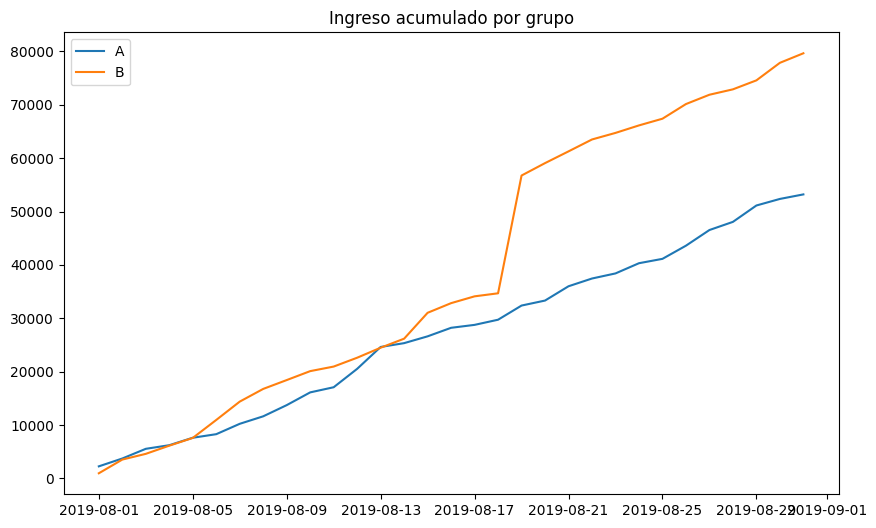

In [29]:
plt.figure(figsize=(10, 6))
plt.title('Ingreso acumulado por grupo')
plt.plot(ingreso_acumulado_a['date'], ingreso_acumulado_a['revenue'], label='A')
plt.plot(ingreso_acumulado_b['date'], ingreso_acumulado_b['revenue'], label='B')
plt.legend()

In [30]:
#Tamaño del pedido promedio acumulado por grupo
promedio_acumulado_a = ingreso_acumulado_a['revenue']/ingreso_acumulado_a['orders']

promedio_acumulado_b = ingreso_acumulado_b['revenue']/ingreso_acumulado_b['orders']

In [31]:
#Podemos observar que los ingresios al principio no tienen una diferencia significativa en cuanto a los ingresos, sin embargo, a partir de la fecha 2019-08-17, se ve una clara superioridad del Grupo B

## 2. Grafico del tamaño de pedido promedio acumulado por grupo

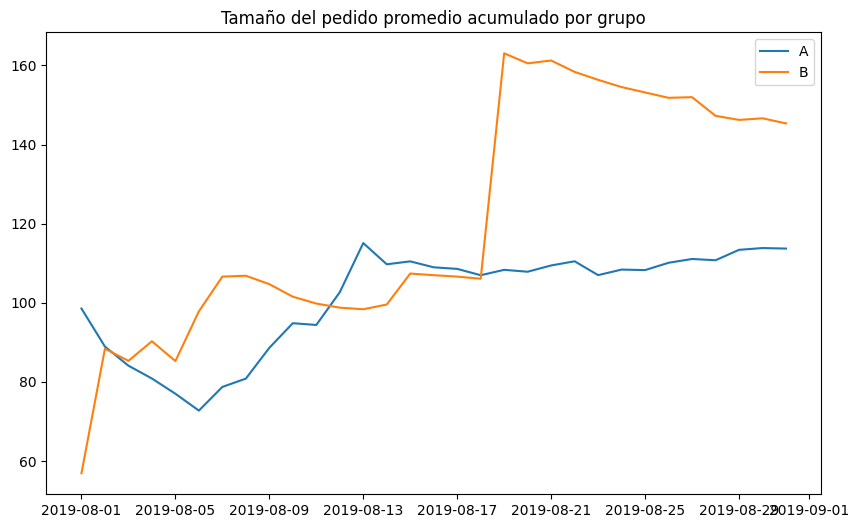

In [32]:
plt.figure(figsize=(10, 6))
plt.title('Tamaño del pedido promedio acumulado por grupo')
plt.plot(ingreso_acumulado_a['date'], promedio_acumulado_a, label='A')
plt.plot(ingreso_acumulado_b['date'], promedio_acumulado_b, label='B')
plt.legend()

In [33]:
#Nuevamente vemos que al inicio los el tamaño promedio acumulado fluctua mucho en ambos grupos, pero nuevamente a partir de la fecha 2019-08-21 se ve una clara superioridad del grupo B

In [34]:
# Obtendremos un Dataframe mergedCumulativeRevenue que nos va a permitir obtener la diferencia relativa entre el tamaño promedio de compra acumulado para el grupo B en comparacion al grupo A
mergedCumulativeRevenue = ingreso_acumulado_a.merge(ingreso_acumulado_b, on='date', how='left', suffixes=['A','B'])
mergedCumulativeRevenue.head()

,date,revenueA,ordersA,revenueB,ordersB
0,2019-08-01,2266.6,23,967.2,17
1,2019-08-02,3734.9,42,3535.3,40
2,2019-08-03,5550.1,66,4606.9,54
3,2019-08-04,6225.6,77,6138.5,68
4,2019-08-05,7623.6,99,7587.8,89


## 3. Grafico de la diferencia relativa en el tamaño de pedido promedio acumulado para el grupo B en comparacion al grupo A

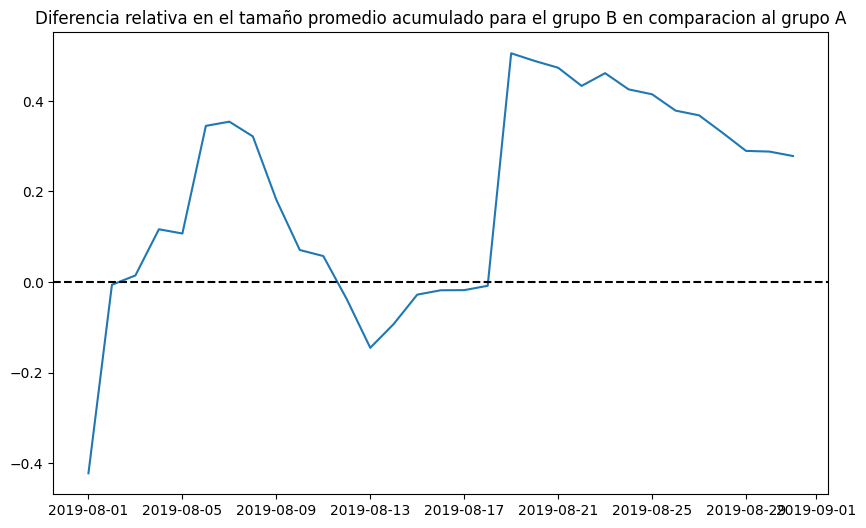

In [35]:

plt.figure(figsize=(10, 6))
plt.title('Diferencia relativa en el tamaño promedio acumulado para el grupo B en comparacion al grupo A')
plt.plot(mergedCumulativeRevenue['date'], (mergedCumulativeRevenue['revenueB']/mergedCumulativeRevenue['ordersB'])/(mergedCumulativeRevenue['revenueA']/mergedCumulativeRevenue['ordersA'])- 1)
plt.axhline(y=0, color= 'black', linestyle ='--')


In [36]:
# vemos una diferencia significativamene positiva del grupo B con respecto al A
# Podria considererarse detener la prueba, ya que con la informacion y graficos obtenidos, vemos claramente que el grupo B es superior al A, aunque aun hace falta hacer el analsisis sin los datos atipicos en ambos grupos

## 4 Tasa de convercion de cada grupo

In [37]:
#Se añade una columna 'conversion' con el calculo de la tasa de conversion
data_acumulada['conversion'] = data_acumulada['orders'] / data_acumulada['visitors']

In [38]:
#Hacemos los filtros para cada uno de los grupos
conversion_a = data_acumulada[data_acumulada['group']=='A']
conversion_b = data_acumulada[data_acumulada['group']=='B']

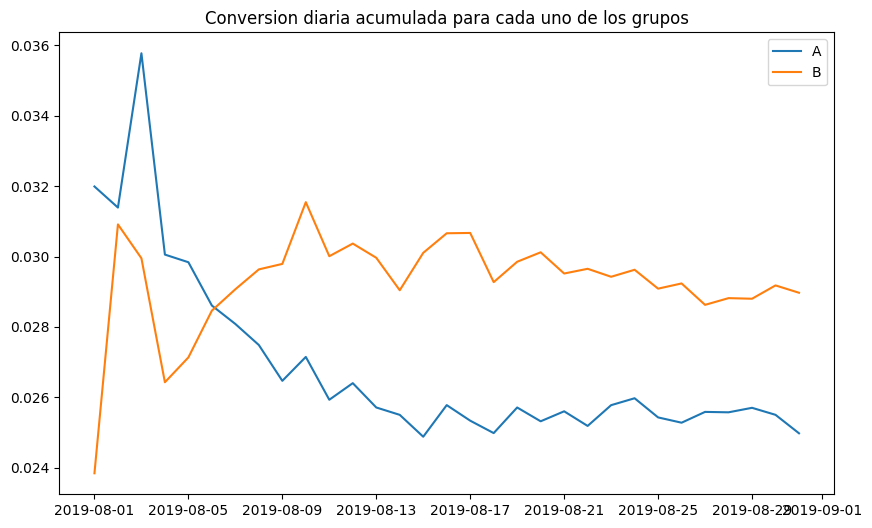

In [39]:


#Obtenemos la grafica de la conversion acumulada de cada grupo
plt.figure(figsize=(10,6))
plt.title('Conversion diaria acumulada para cada uno de los grupos')
plt.plot(conversion_a['date'], conversion_a['conversion'], label='A')
plt.plot(conversion_b['date'], conversion_b['conversion'], label='B')
plt.legend()



# 5 Dispersion del número de pedidos por usuario

In [40]:
#Obtenemos un dataframe con las ordenes por usuario a partir de orders_df
orders_users = filtered_orders.groupby('visitorId', as_index=False).agg({'transactionId':pd.Series.nunique}).sort_values(by='transactionId', ascending=False)
orders_users.columns = ['visitorId', 'orders']
orders_users.head()

,visitorId,orders
908,3967698036,3
55,249864742,3
478,2108163459,3
687,2988190573,3
890,3908431265,3


In [41]:
#Rango de números desde 0 hasta el numero de eventos en orders_users
x_value = pd.Series(range(0, len(orders_users)))

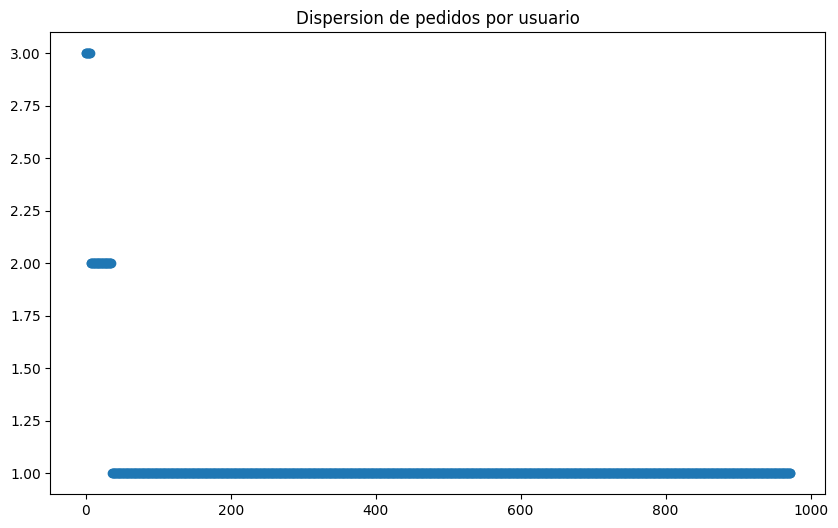

In [42]:
plt.figure(figsize=(10,6))
plt.title('Dispersion de pedidos por usuario')
plt.scatter(x_value,orders_users['orders'])
plt.show()

In [43]:
#Se observa que los clientes hicieron entre 1 y 3 pedidos, pero la gran mauyoria hizo unicamente 1 pedido

# 6 Se calculan los percentiles 95, y 99 del numero de pedidos por usuario.

In [44]:
print(np.percentile(orders_users['orders'], [95, 99]))

[1. 2.]


In [45]:
#Se observa que no mas del 5% de los usuarios realizaron mas de un pedido, y nomas del 1% realizó mas de dos pedidos
#Se determina que realizar mas de un pedido es una anomalia

# 7 Se traza un grafico de dispersion con los precios de los pedidos

In [46]:
order_price = filtered_orders.groupby('transactionId')

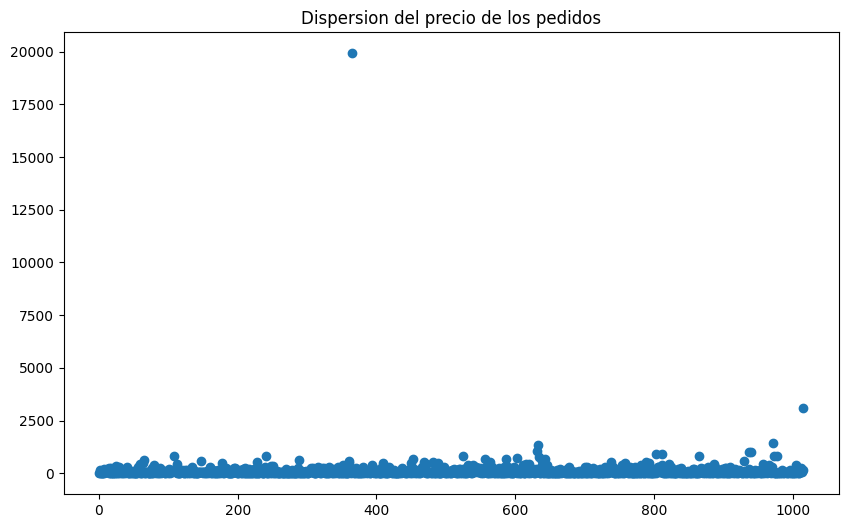

In [47]:
plt.figure(figsize=(10,6))
plt.title('Dispersion del precio de los pedidos')
plt.scatter(pd.Series(range(0, len(filtered_orders['revenue']))),filtered_orders['revenue'])
plt.show()

In [48]:
#Se puede observar que el costo de la mayoria de los pedidos es de alrededor de 500

# 8 Se calcula los percentiles de los precios de los pedidos

In [49]:
print(np.percentile(filtered_orders['revenue'], [95, 99]))

[414.275 830.3  ]


In [50]:
#Se encuentra que no mas del 95% de las ordenes tuvo un costo de 414, mientras que no mas del 99% tuvo un costo mayor a 800

# 9 Significancia estadistica de la diferencia entre la conversion de grupos a partir de los datos en bruto

In [51]:
filtered_orders.head()

,index,transactionId,visitorId,date,revenue,group
0,0,3667963787,3312258926,2019-08-15,30.4,B
1,1,2804400009,3642806036,2019-08-15,15.2,B
2,3,3797467345,1196621759,2019-08-15,155.1,B
3,4,2282983706,2322279887,2019-08-15,40.5,B
4,5,182168103,935554773,2019-08-15,35.0,B


In [52]:
#Obtenemos los datos de la cantidad de ordenes realizadas por ambos grupos, y los visitantes de cada uno
orders_group_a = filtered_orders[filtered_orders['group'] =='A'].groupby('visitorId', as_index=False).agg({'transactionId':pd.Series.nunique})
orders_group_a.columns = ['visitorId', 'orders']

orders_group_b = filtered_orders[filtered_orders['group']=='B'].groupby('visitorId', as_index=False).agg({'transactionId':pd.Series.nunique})
orders_group_b.columns = ['visitorId', 'orders']

In [53]:
#Obtenemos las muestras para calcular las diferencia relativa
sample_a = pd.concat([orders_group_a['orders'], pd.Series(0, index=np.arange(visits_df[visits_df['group']=='A']['visits'].sum() - len(orders_group_a['orders'])), name='orders')], axis=0)

sample_b = pd.concat([orders_group_b['orders'], pd.Series(0, index=np.arange(visits_df[visits_df['group']=='B']['visits'].sum() - len(orders_group_b['orders'])), name='orders')], axis=0)

In [54]:
#Aplicamos la prueba de Mann-Whitney y calculamos la diferencia relativa


print('valor p: ','{0:.5f}'.format(stats.mannwhitneyu(sample_a, sample_b)[1]))
print('diferencia relativa: ','{0:.3f}'.format(sample_b.mean() / sample_a.mean() - 1))



valor p:  0.01102
diferencia relativa:  0.160


In [55]:
#Encontramos que el valor p es claramente menor a 0.05%, por lo que podemos concluir que el analisi de los datos demuestra que existe una diferencia estsadisitica considerable entre ambos grupos
#La ganancia de conversion en el grupo B es superior en 16% contra el grupo A

# 10 Siginificancia estadistica de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos en bruto

In [56]:
#Obtenemos los datos de las ordenes y precio para cada uno de los grupos
mean_order_price_a = filtered_orders[filtered_orders['group']=='A']['revenue']

mean_order_price_b = filtered_orders[filtered_orders['group']=='B']['revenue']


In [57]:
#Aplicamos la prueba de Mann-Whitney y obtenemos la diferencia relativa
print('valor p: ','{0:.5f}'.format(stats.mannwhitneyu(mean_order_price_a, mean_order_price_b)[1]))
print('diferencia relativa: ','{0:.3f}'.format(mean_order_price_b.mean() / mean_order_price_a.mean() - 1))


valor p:  0.86223
diferencia relativa:  0.278


In [58]:
#Dado que el valor P es mucho mayor a 0.05, podemos concluir que no existe una diferencia significativa entre el tamaño promedio de las ordenes de cada uno de los grupos
#El tamaño promedio de compra del grupo B es mayor al del grupo A

# 11 Significancia estadistica de la diferencia en la conversion entre los grupos con los datos filtrados

In [59]:
#Se considerará como anomalos a los usuarios con mas de un pedido, y/o con un valor de compra mayor a 414.275

In [60]:
filtered_orders.head()

,index,transactionId,visitorId,date,revenue,group
0,0,3667963787,3312258926,2019-08-15,30.4,B
1,1,2804400009,3642806036,2019-08-15,15.2,B
2,3,3797467345,1196621759,2019-08-15,155.1,B
3,4,2282983706,2322279887,2019-08-15,40.5,B
4,5,182168103,935554773,2019-08-15,35.0,B


In [61]:
#Obtenemos el filtrado de ambos tipos de compradores
users_orders_qty = filtered_orders.groupby('visitorId')['transactionId'].count().reset_index()
users_orders_qty.columns = ['visitorId', 'orders']

users_with_many_orders = users_orders_qty[users_orders_qty['orders']>1]['visitorId']

users_with_expensive_orders = filtered_orders[filtered_orders['revenue']>414.275]['visitorId']

abnormal_users = pd.concat([users_with_many_orders, users_with_expensive_orders], axis=0).drop_duplicates()
abnormal_users.head()

55     249864742
82     366673373
94     406208401
118    522292794
138    611059232
Name: visitorId, dtype: int64

In [62]:
#Cantidad de usuarios anormales (con mas de un pedido y/o compras mayores a 414.275)
abnormal_users.nunique()

86

In [63]:
#cantidad unica de usuarios
filtered_orders['visitorId'].nunique()

973

In [64]:
#Obtenemos un datframe eliminando a estos usuarios
orders_without_anormal_users = filtered_orders[~filtered_orders['visitorId'].isin(abnormal_users)].reset_index(drop=True)

In [65]:
orders_without_anormal_users.head()

,index,transactionId,visitorId,date,revenue,group
0,0,3667963787,3312258926,2019-08-15,30.4,B
1,1,2804400009,3642806036,2019-08-15,15.2,B
2,3,3797467345,1196621759,2019-08-15,155.1,B
3,4,2282983706,2322279887,2019-08-15,40.5,B
4,5,182168103,935554773,2019-08-15,35.0,B


In [66]:
#Verificamos que se haya eliminado la cantidad correspodiente de visitantes
orders_without_anormal_users['visitorId'].nunique()

887

In [67]:
#Obtenemos dataframes para cada uno de los gruipos

filtered_orders_a = orders_without_anormal_users[orders_without_anormal_users['group']=='A'].groupby('visitorId', as_index=False).agg({'transactionId':pd.Series.nunique})
filtered_orders_b = orders_without_anormal_users[orders_without_anormal_users['group']=='B'].groupby('visitorId', as_index=False).agg({'transactionId':pd.Series.nunique})

In [68]:
#Ahora haremos la comparacion de los datos filtrados para obtener la diferencia en la conversion
sample_a_filtered = pd.concat([filtered_orders_a['transactionId'], pd.Series(0, index=np.arange(visits_df[visits_df['group']=='A']['visits'].sum() -len(filtered_orders_a['transactionId'])), name='transactionId')], axis=0)


sample_b_filtered = pd.concat([filtered_orders_b['transactionId'], pd.Series(0, index=np.arange(visits_df[visits_df['group']=='B']['visits'].sum() -len(filtered_orders_b['transactionId'])), name='transactionId')], axis=0)


In [69]:

#Imprimimos el valor p y la diferencia significativa entre la conversion de los grupos con los datos filtrados

print('valor p: ','{0:.5f}'.format(stats.mannwhitneyu(sample_a_filtered,sample_b_filtered)[1]))
print('diferencia relativa: ','{0:.3f}'.format(sample_b_filtered.mean() / sample_a_filtered.mean() - 1))





valor p:  0.01620
diferencia relativa:  0.173


In [70]:
#Nuevamente observamos que si exisate una diferencia estadisticamente significativa entre ambos grupos
#El grupo B vuelve a ser superior al grupo A en la tasa de conversion con los datos filtrados por un 17.3%

# 12 Significancia estadistica en la diferencia del tamaño promedio de pedido entre los grupos utilizando los datos filtrados

In [71]:
#Obtenemos el revenue para cada uno de los grupos

mean_revenue_filtered_orders_a = orders_without_anormal_users[orders_without_anormal_users['group']=='A']['revenue']
mean_revenue_filtered_orders_b = orders_without_anormal_users[orders_without_anormal_users['group']=='B']['revenue']


In [72]:
#Imprimimos el valor p y la diferencia significativa entre el tamaño promedio del pedido de ambos grupos

print('valor p: ','{0:.5f}'.format(stats.mannwhitneyu(mean_revenue_filtered_orders_a,mean_revenue_filtered_orders_b)[1]))
print('diferencia relativa: ','{0:.3f}'.format(mean_revenue_filtered_orders_b.mean() / mean_revenue_filtered_orders_a.mean() - 1))


valor p:  0.77119
diferencia relativa:  -0.033


In [73]:
#El valor P es mucho mayor a 0.05, por lo que una vez mas confirmamos que no existe una diferencia significativa entre los datos de los ambos grupos aun cuando estos han sido filtrados
#Una vez filtrados los datos podemos observar que el tamaño promedio de compra es ligeramente inferior en el caso del grupo B

# 13 Conclusiones para designar al grupo B como lider

Se encontró que existe una diferencia estadistica significativa en cuanto a la tasa de conversion de ambos grupos, donde se corona el grupo B como lider tanto en los datos con usuarios anormales y los datos sin usuarios anormales. Por otro lado, no se detecto diferencia estadisticamente significativa entre el tamaño promedio de compra de ambos grupos, con o sin usuarios anormales.

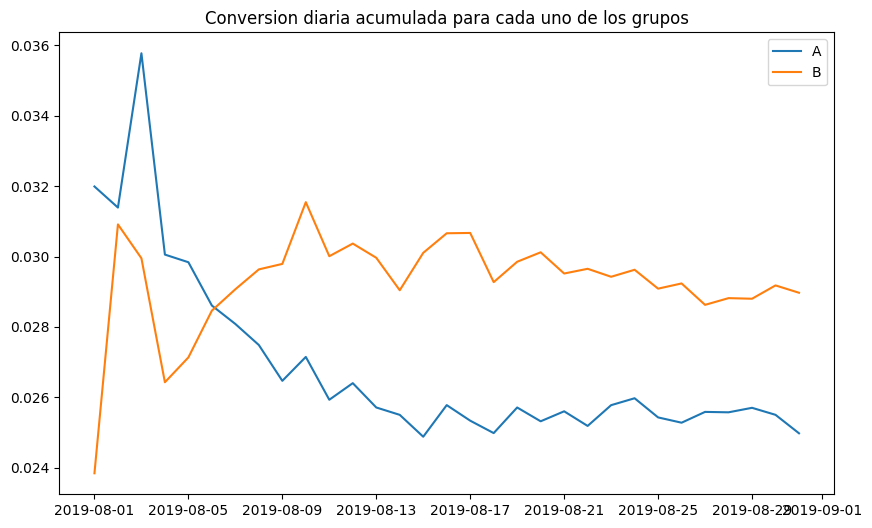

In [74]:
#Obtenemos la grafica de la conversion acumulada de cada grupo
plt.figure(figsize=(10,6))
plt.title('Conversion diaria acumulada para cada uno de los grupos')
plt.plot(conversion_a['date'], conversion_a['conversion'], label='A')
plt.plot(conversion_b['date'], conversion_b['conversion'], label='B')
plt.legend()


Podemos ver como la tasa de conversion del grupo B es claramente mayor a la tasa de conversion del grupo A

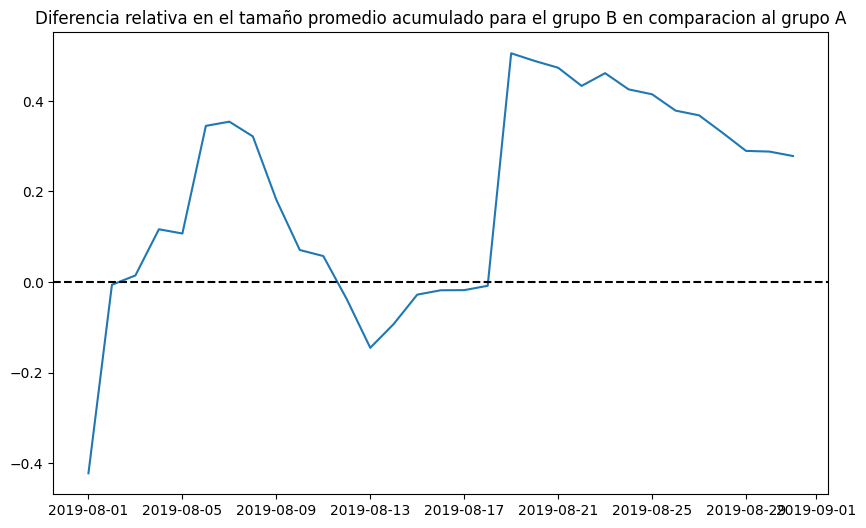

In [75]:
plt.figure(figsize=(10, 6))
plt.title('Diferencia relativa en el tamaño promedio acumulado para el grupo B en comparacion al grupo A')
plt.plot(mergedCumulativeRevenue['date'], (mergedCumulativeRevenue['revenueB']/mergedCumulativeRevenue['ordersB'])/(mergedCumulativeRevenue['revenueA']/mergedCumulativeRevenue['ordersA'])- 1)
plt.axhline(y=0, color= 'black', linestyle ='--')

En el caso de la diferencia relativa del tamaño promedio del pedido, vemos que al principio hay fluctuaciones, pero conforme pasan los dias, el grupo B se posiciona por encima del grupo A

Se decide finalizar la prueba y se determina que el grupo B es lider.